# 0. import

In [ ]:
# --- plot_revision setup (auto-injected) ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.lines import Line2D

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches

from plot_settings import *

from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


In [2]:
chromosomes = {
    'human': [9,10],
    'mouse': [1,2,3,4]
}

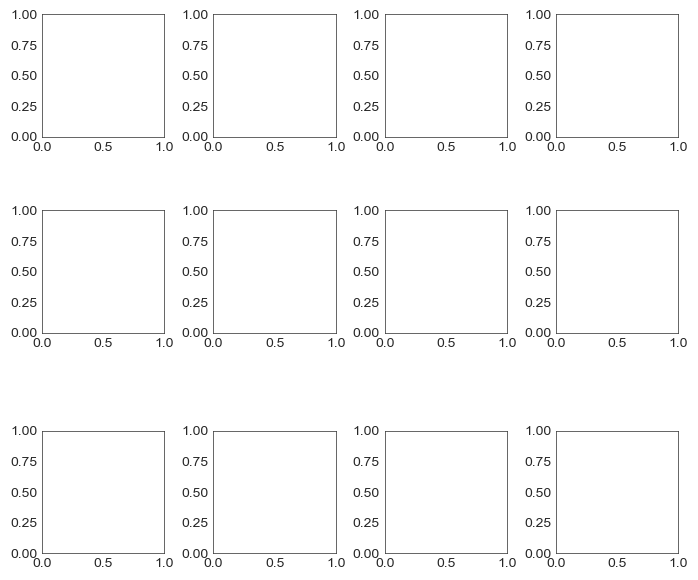

In [3]:
fig = plt.figure(figsize=(8.27, 7))

gs = gridspec.GridSpec(
    5, 4,  
    figure=fig,
    height_ratios=[1, 0.6, 1, 0.8, 1],
    hspace=0.0,
    wspace=0.35
)

axes = []
for i, row in enumerate([0, 2, 4]):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[row, j])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)
for ax in axes.flatten():
    ax.set_aspect('equal')
    # ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


In [4]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 1 Embedding similarity

In [5]:
def read(f, norm=True):
    emb = np.load(f)
    emb = emb.transpose(-1, -2)
    if norm:
        emb /= np.linalg.norm(emb, axis=-1, keepdims=True)
    emb = np.nan_to_num(emb)
    return emb
def compute_density(x, y):
    xy = np.vstack([x, y])
    return gaussian_kde(xy)(xy)


In [6]:
emb_train_evo2 = np.concatenate([
    np.memmap(str(EVO2_EMB_HUMAN / 'chr9.embedding'), mode='r', dtype=np.float16, shape=(69198, 4096)).copy().astype(np.float32),
    np.memmap(str(EVO2_EMB_HUMAN / 'chr9.rev.embedding'), mode='r', dtype=np.float16, shape=(69198, 4096)).copy().astype(np.float32)
], axis=-1)
emb_train_evo2 /= np.linalg.norm(emb_train_evo2, axis=-1, keepdims=True)

emb_train_evohic    = read(str(PRETRAIN_CKPT_DIR / 'human_embeds/dna_emb_9.npy'))
emb_train_alignment = read(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human_embeds/dna_emb_9.npy'))

def pad1(x):
    return np.pad(x, ((0,0), (1,0)), constant_values=1)

def find_proj_emb(emb_s, emb_t):
    A = np.linalg.lstsq(pad1(emb_s), emb_t)[0]
    return A

proj0 = find_proj_emb(emb_train_evohic, emb_train_evo2)
proj1 = find_proj_emb(emb_train_alignment, emb_train_evo2)

/tmp/ipykernel_1491829/2078043305.py:5: RuntimeWarning: invalid value encountered in divide
  emb /= np.linalg.norm(emb, axis=-1, keepdims=True)
/tmp/ipykernel_1491829/1591413855.py:14: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  A = np.linalg.lstsq(pad1(emb_s), emb_t)[0]


## Human

In [7]:
emb_evo2_human = np.concatenate([
    np.memmap(str(EVO2_EMB_HUMAN / 'chr10.embedding'), mode='r', dtype=np.float16, shape=(66899, 4096)).copy().astype(np.float32),
    np.memmap(str(EVO2_EMB_HUMAN / 'chr10.rev.embedding'), mode='r', dtype=np.float16, shape=(66899, 4096)).copy().astype(np.float32)
], axis=-1)
emb_evo2_human /= np.linalg.norm(emb_evo2_human, axis=-1, keepdims=True)

emb_evohic_human    = read(str(PRETRAIN_CKPT_DIR / 'human_embeds/dna_emb_10.npy'))
emb_evohic_human_proj = pad1(emb_evohic_human) @ proj0

emb_alignment_human = read(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human_embeds/dna_emb_10.npy'))
emb_alignment_human_proj = pad1(emb_alignment_human) @ proj1


/tmp/ipykernel_1491829/2078043305.py:5: RuntimeWarning: invalid value encountered in divide
  emb /= np.linalg.norm(emb, axis=-1, keepdims=True)


In [8]:
def get_sims(emb_evo2, emb_evohic_proj, emb_alignment_proj):
    np.random.seed(42)
    N = 5000
    ind0 = np.random.choice(emb_evo2.shape[0]-1000, N)+500
    ind1 = np.random.choice(emb_evo2.shape[0]-1001, N)+500
    ind1 = ind1 + (ind1>=ind0)

    sim_evo2 = (emb_evo2[ind0] * emb_evo2[ind1]).sum(axis=-1)
    sim0 = (emb_evohic_proj[ind0] * emb_evohic_proj[ind1]).sum(axis=-1)
    sim1 = (emb_alignment_proj[ind0] * emb_alignment_proj[ind1]).sum(axis=-1)

    return sim_evo2, sim0, sim1

In [9]:
Xh, Yh, Zh = get_sims(emb_evo2_human, emb_evohic_human_proj, emb_alignment_human_proj)

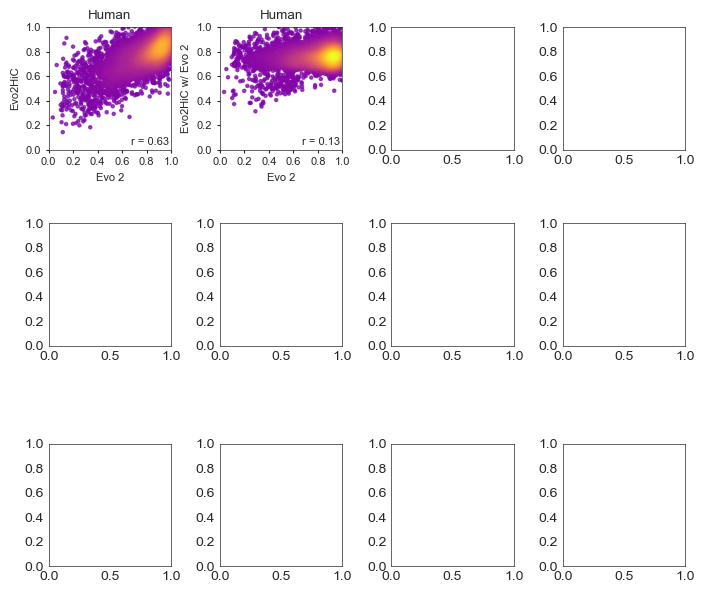

In [10]:
def compute_density(x, y):
    xy = np.vstack([x, y])
    return gaussian_kde(xy)(xy)

def plot_sims(X, Y, Z, ax1, ax2, title="Human"):
    cmap = 'plasma'

    # Compute densities
    density_xy = compute_density(X, Y)
    density_xz = compute_density(X, Z)
    all_densities = np.concatenate([density_xy, density_xz])
    vmax = all_densities.max()
    vmin = -vmax*0.3
    
    # === First scatter ===
    ax1.clear()
    for spine in ax1.spines.values():
        spine.set_linewidth(0.5)

    idx = density_xy.argsort()
    sc1 = ax1.scatter(X[idx], Y[idx], c=density_xy[idx], s=5, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.7, rasterized=True)
    r1, _ = spearmanr(X, Y)
    ax1.text(
        0.98, 0.02, f"r = {r1:.2f}",
        ha='right', va='bottom', transform=ax1.transAxes, fontsize=8
    )

    ax1.set_xlabel("Evo 2")
    ax1.set_ylabel("Evo2HiC")
    ax1.set_box_aspect(1)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax1.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax1.set_title(title)

    # === Second scatter ===
    ax2.clear()
    for spine in ax2.spines.values():
        spine.set_linewidth(0.5)

    idx = density_xz.argsort()
    sc2 = ax2.scatter(X[idx], Z[idx], c=density_xz[idx], s=5, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.7)
    r2, _ = spearmanr(X, Z)
    ax2.text(
        0.98, 0.02, f"r = {r2:.2f}",
        ha='right', va='bottom', transform=ax2.transAxes, fontsize=8
    )

    ax2.set_xlabel("Evo 2")
    ax2.set_ylabel("Evo2HiC w/o Evo 2")
    ax2.set_box_aspect(1)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax2.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax2.set_title(title)

    ax1.tick_params(axis='both', which='both', length=2)
    ax2.tick_params(axis='both', which='both', length=2)

# 调用示例
plot_sims(Xh, Yh, Zh, axes[0][0], axes[0][1], title="Human")
fig


## Mouse

In [11]:
emb_evo2_mouse = np.concatenate([
    np.memmap(str(EVO2_EMB_MOUSE / 'chr4.embedding'), mode='r', dtype=np.float16, shape=(78255, 4096)).copy().astype(np.float32),
    np.memmap(str(EVO2_EMB_MOUSE / 'chr4.rev.embedding'), mode='r', dtype=np.float16, shape=(78255, 4096)).copy().astype(np.float32)
], axis=-1)
emb_evo2_mouse /= np.linalg.norm(emb_evo2_mouse, axis=-1, keepdims=True)

emb_evohic_mouse    = read(str(PRETRAIN_CKPT_DIR / 'mouse_embeds/dna_emb_4.npy'))
emb_evohic_mouse_proj = pad1(emb_evohic_mouse) @ proj0
emb_alignment_mouse = read(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/mouse_embeds/dna_emb_4.npy'))
emb_alignment_mouse_proj = pad1(emb_alignment_mouse) @ proj1

/tmp/ipykernel_1491829/2078043305.py:5: RuntimeWarning: invalid value encountered in divide
  emb /= np.linalg.norm(emb, axis=-1, keepdims=True)


In [12]:
Xm, Ym, Zm = get_sims(emb_evo2_mouse, emb_evohic_mouse_proj, emb_alignment_mouse_proj)

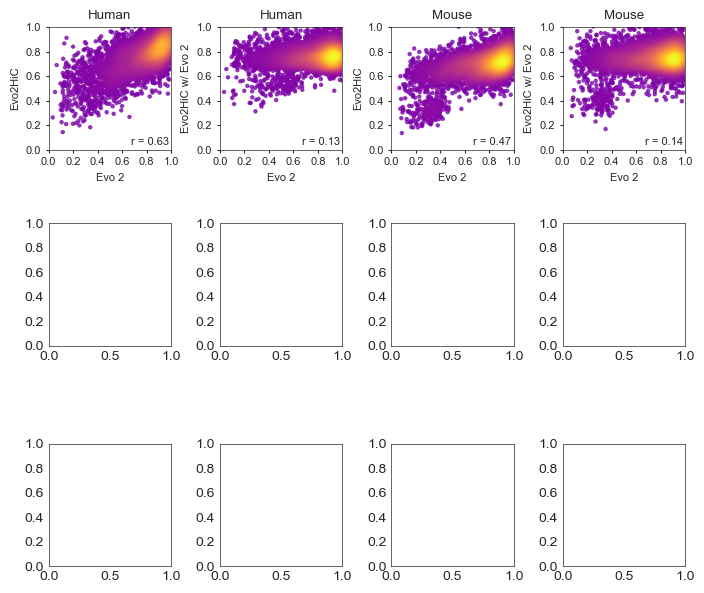

In [13]:
plot_sims(Xm, Ym, Zm, axes[0][2], axes[0][3], title='Mouse')
fig

# 2. HiC Retrieval

In [23]:
cell2accession = {
    'human' : {
        #human
        'GM12878': 'ENCFF555ISR', 'H1-hESC': '4DNFIQYQWPF5', 'HepG2': '4DNFICSTCJQZ', 'IMR-90': 'ENCFF188SSH', 'K562': 'ENCFF616PUW', 'B cell': 'ENCFF076LWH'
    },
    'mouse' : {
        #mouse
        '46C' : '4DNFIHW8NTQX', 'B cell' : '4DNFI57XB4A8', 'mESC': '4DNFI4OUMWZ8', 'ORC': '4DNFI2U38HCE', 
    }
}


## 2.1 Similarity gap(deprecated)

In [15]:
# def get_similarity_gaps(data_dir, name, species):
#     gap_data = []
#     for cell, accession in tqdm(cell2accession[species].items()):
#         for ch in chromosomes[species]:
#             sim_pos_file = os.path.join(data_dir, accession, f'sim_pos_{ch}.npy')
#             sim_neg_file = os.path.join(data_dir, accession, f'sim_neg_{ch}.npy')
            
#             pos_values = np.load(sim_pos_file)
#             neg_values = np.load(sim_neg_file)

#             ids = np.random.choice(pos_values.shape[0], 10000)

#             gaps = pos_values[ids] - neg_values[ids]

#             gap_data.extend([(cell, name, v) for v in gaps])
    
#     return gap_data


In [16]:
# gaps_evohic_human = get_similarity_gaps(str(PRETRAIN_CKPT_DIR / 'human'), 'EvoHiC', 'human')
# gaps_align_human = get_similarity_gaps(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human'), 'Alignment', 'human')

# gap_human = pd.DataFrame(gaps_evohic_human + gaps_align_human, columns=['CellType', 'SampleType', 'Value'])
# gap_human.to_csv(str(RESULT_RETRIEVAL_DIR / 'gap_human.csv'), index=False, sep = '\t')

In [17]:
# gaps_evohic_mouse = get_similarity_gaps(str(PRETRAIN_CKPT_DIR / 'mouse'), 'EvoHiC', 'mouse')
# gaps_align_mouse = get_similarity_gaps(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/mouse'), 'Alignment', 'mouse')

# gap_mouse = pd.DataFrame(gaps_evohic_mouse + gaps_align_mouse, columns=['CellType', 'SampleType', 'Value'])
# gap_mouse.to_csv(str(RESULT_RETRIEVAL_DIR / 'gap_mouse.csv'), index=False, sep = '\t')

## 2.2 Rank

In [24]:
def get_ranks(data_dir, name, species):
    rank_data = []
    for cell, accession in tqdm(cell2accession[species].items()):
        for ch in chromosomes[species]:
            if ch==9: continue
            rank_file = os.path.join(data_dir, accession, f'rank_{ch}.npy')

            ranks = np.load(rank_file)

            filtered = ranks[ranks >= 0]

            ids = np.random.choice(filtered.shape[0], 50000)

            rank_data.extend([(cell, name, v) for v in filtered[ids]])
    
    return rank_data


In [25]:
ranks_evohic_human = get_ranks(str(PRETRAIN_CKPT_DIR / 'human_mask'), 'Evo2HiC', 'human')
ranks_align_human = get_ranks(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human_mask'), 'Evo2HiC w/o Evo 2', 'human')

rank_human = pd.DataFrame(ranks_evohic_human + ranks_align_human, columns=['CellType', 'Method', 'Value'])
rank_human.to_csv(str(RESULT_RETRIEVAL_DIR / 'rank_human.csv'), index=False, sep = '\t')

100%|██████████| 6/6 [00:00<00:00, 18.34it/s]


In [26]:
ranks_evohic_mouse = get_ranks(str(PRETRAIN_CKPT_DIR / 'mouse_mask'), 'Evo2HiC', 'mouse')
ranks_align_mouse = get_ranks(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/mouse_mask'), 'Evo2HiC w/o Evo 2', 'mouse')

rank_mouse = pd.DataFrame(ranks_evohic_mouse + ranks_align_mouse, columns=['CellType', 'Method', 'Value'])
rank_mouse.to_csv(str(RESULT_RETRIEVAL_DIR / 'rank_mouse.csv'), index=False, sep = '\t')

100%|██████████| 4/4 [00:01<00:00,  3.97it/s]


/tmp/ipykernel_1491829/690226369.py:10: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.pointplot(


/tmp/ipykernel_1491829/690226369.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_1491829/690226369.py:10: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.pointplot(


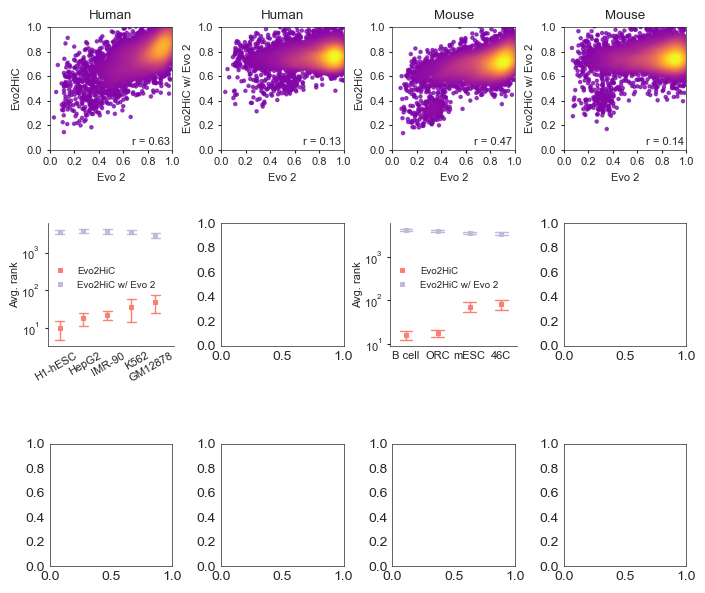

In [30]:
cell_human = ['H1-hESC', 'HepG2', 'IMR-90', 'K562', 'GM12878']
cell_mouse = ['B cell', 'ORC', 'mESC', '46C']

def plot_std(data, orders, ax, title='', rotate=0):
    ax.clear()
    ax.set_aspect('auto')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    
    sns.pointplot(
        data=data, 
        x='CellType', 
        y='Value', 
        hue='Method', 
        palette=colors, 
        dodge=0, 
        capsize=0.4, 
        order=orders, 
        markers='s', 
        linestyle='none', 
        linewidth=1, 
        ax=ax, 
        legend=True,
        errorbar=('se', 10)
    )

    sns.despine(ax=ax)

    if rotate:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
        ax.set_xticks([p+0.8 for p in ax.get_xticks()])

    ax.set_xlabel('')
    ax.set_ylabel('Avg. rank')
    ax.set_yscale('log')
    ax.tick_params(axis='y', length=2)
    ax.minorticks_off()
    # ax.set_ylim(1, 1000)
    ax.xaxis.labelpad = 1
    ax.yaxis.labelpad = 1
    # ax.set_title(title)

    ax.legend(
        title=None,
        frameon=False,
        loc='center left',          # 图例左边在左侧中点附近
        bbox_to_anchor=(-0.05, 0.55),  # x 负值：往图外左移；y=0.5 是中点，0.6 就是略上方
        fontsize=7,
    )


plot_std(rank_human, cell_human, axes[1][0], 'Human', rotate=30)
plot_std(rank_mouse, cell_mouse, axes[1][2], 'Mouse')
fig


## 2.3 Recall

In [22]:
recall_evohic_human = pd.read_csv(str(PRETRAIN_CKPT_DIR / 'human_mask/recall.tsv'), sep='\t')
recall_evohic_human['Method'] = 'Evo2HiC'
recall_align_human = pd.read_csv(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human_mask/recall.tsv'), sep='\t')
recall_align_human['Method'] = 'Evo2HiC w/o Evo 2'
recall_human = pd.concat([recall_evohic_human, recall_align_human])


In [23]:
recall_evohic_mouse = pd.read_csv(str(PRETRAIN_CKPT_DIR / 'mouse_mask/recall.tsv'), sep='\t')
recall_evohic_mouse['Method'] = 'Evo2HiC'
recall_align_mouse = pd.read_csv(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/mouse_mask/recall.tsv'), sep='\t')
recall_align_mouse['Method'] = 'Evo2HiC w/o Evo 2'
recall_mouse = pd.concat([recall_evohic_mouse, recall_align_mouse])

In [22]:
def plot_recall(recall_df, species, ax, methods = ['Evo2HiC', 'Evo2HiC w/o Evo 2'], metrics = ['Recall@1', 'Recall@5', 'Recall@10'], rotate=0):
    ax.clear()
    ax.set_aspect('auto')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    x_pos = {metric: i for i, metric in enumerate(metrics)}
    offset = 0.2

    for i, method in enumerate(methods):
        for j, metric in enumerate(metrics):
            values = recall_df[recall_df['Method'] == method][metric]
            if len(values) == 0:
                continue
            shift = -offset if i == 0 else offset
            pos = x_pos[metric] + shift

            ax.boxplot(
                values,
                positions=[pos],
                widths=0.3,
                patch_artist=True,
                boxprops=dict(facecolor='none', color=colors[i], linewidth=0.5),
                medianprops=dict(color=colors[i], linewidth=0.5),
                whiskerprops=dict(color=colors[i], linewidth=0.5),
                capprops=dict(color=colors[i], linewidth=0.5),
                showfliers=False
            )

    # Overlay stripplot
    df_melted = recall_df.melt(id_vars=['Name', 'Chr', 'Method'], value_vars=metrics,
                                var_name='Metric', value_name='Recall')
    sns.stripplot(
        data=df_melted,
        x='Metric',
        y='Recall',
        hue='Method',
        dodge=True,
        palette=colors,
        linewidth=0.5,
        edgecolor='none',
        alpha=0.8,
        marker='o',
        ax=ax,
        size=2
    )
    if rotate>0:
        ax.set_xticks([p+0.3 for p in x_pos.values()])
        ax.set_xticklabels(metrics, rotation=rotate,ha='right')
    else:
        display_name = [m.replace('Recall', 'R') for m in metrics]
        ax.set_xticks([p for p in x_pos.values()])
        ax.set_xticklabels(display_name)
    # ax.set_title(species)
    ax.set_xlabel('')
    ax.set_xlim(-0.5, len(metrics) - 0.5)
    ax.legend_.remove()
    ax.set_ylabel("Recall")
    ax.tick_params(axis='y', length=2)
    # ax.set_title(species)

    sns.despine(ax=ax)

plot_recall(recall_human, 'Human', axes[1][1])
plot_recall(recall_human, 'Human', axes[1][3])

# from plot_utils import plot_grouped_box_with_points

# metrics = ['Recall@1', 'Recall@5', 'Recall@10']

# recall_human_long = (
#     recall_human.melt(
#         id_vars=['Method'],             # 保留列
#         value_vars=metrics,             # 需要展开的列
#         var_name='Metric', 
#         value_name='Value'
#     )
# )

# # 替换列名中的前缀
# recall_human_long['Metric'] = recall_human_long['Metric'].str.replace('Recall@', 'R@', regex=False)

# recall_mouse_long = (
#     recall_mouse.melt(
#         id_vars=['Method'],             # 保留列
#         value_vars=metrics,             # 需要展开的列
#         var_name='Metric', 
#         value_name='Value'
#     )
# )

# # 替换列名中的前缀
# recall_mouse_long['Metric'] = recall_mouse_long['Metric'].str.replace('Recall@', 'R@', regex=False)

# plot_grouped_box_with_points(recall_human_long, methods = ['Evo2HiC', 'Evo2HiC w/o Evo 2'], metrics = ['R@1', 'R@5', 'R@10'], ax=axes[1][1])
#                             #  pairs_per_group=[('Evo2HiC', 'Evo2HiC w/o Evo 2')] * 3, alternative='greater')
# plot_grouped_box_with_points(recall_mouse_long, methods = ['Evo2HiC', 'Evo2HiC w/o Evo 2'], metrics = ['R@1', 'R@5', 'R@10'], ax=axes[1][3])
#                             #  pairs_per_group=[('Evo2HiC', 'Evo2HiC w/o Evo 2')] * 3, alternative='greater')
fig

NameError: name 'recall_human' is not defined

In [25]:
# pos0, pos1 = axes[1][0].get_position(), axes[1][3].get_position()
# x = (pos0.x0+pos1.x1)/2
# y = pos0.y0 - 0.05

# labels = ['Evo2HiC', 'Evo2HiC w/o Evo 2']

# # 删除旧 legend（防止重复）
# if hasattr(fig, "legend_") and fig.legend_ is not None:
#     fig.legend_.remove()

# handles = [Line2D([0],[0], marker='s', linestyle='', markersize=8,
#                 markerfacecolor=colors[i], markeredgewidth=0, alpha=0.8,
#                 label=m) for i, m in enumerate(labels)]

# # 在左上角单独放 legend
# fig.legend(
#     handles, labels,
#     loc='center',
#     bbox_to_anchor=(x, y),  # 锚点设在左上角稍上方
#     ncol=len(labels),
#     frameon=False,
#     handlelength=2, handleheight=0.8,
#     fontsize=8,           # 字体更小
#     handletextpad=0.4,    # 图例符号与文字间距
#     columnspacing=5,    # 各列间距
#     borderaxespad=0.1     # 与轴的边界间距
# )
# fig

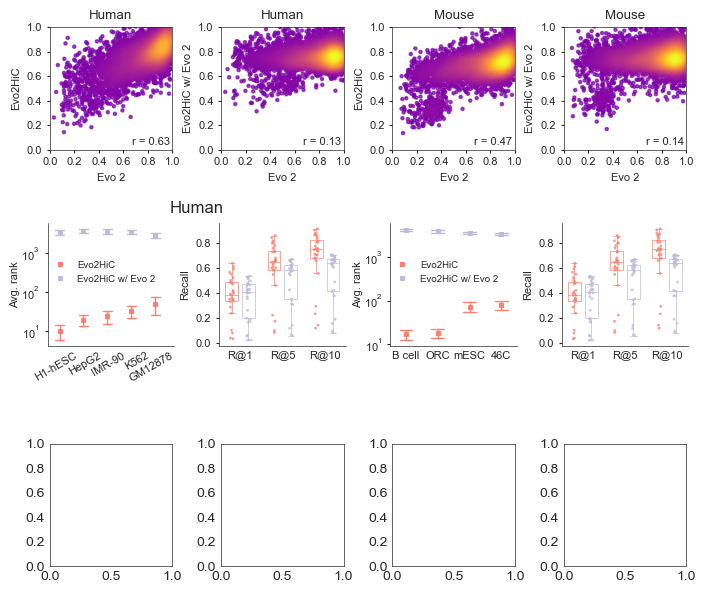

In [26]:
axs = axes[1, 0:2]

# 计算该行最左和最右子图的位置
bbox_left = axs[0].get_position()
bbox_right = axs[-1].get_position()

# 计算该行的水平中心和顶部位置
center_x = (bbox_left.x0 + bbox_right.x1) / 2
top_y = max(ax.get_position().y1 for ax in axs)

# 在这一行上方加一个“局部 suptitle”
fig.text(center_x, top_y + 0.01, "Human", ha='center', va='bottom',
         fontsize=12)


fig

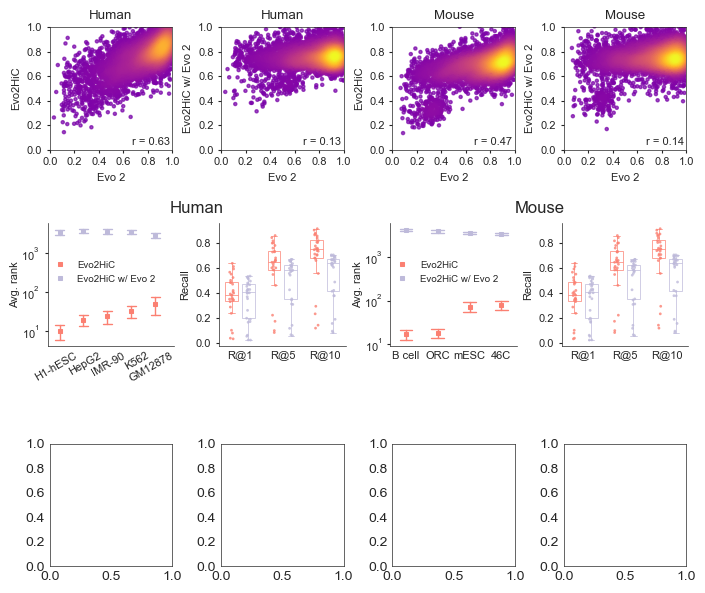

In [27]:
axs = axes[1, 2:4]

# 计算该行最左和最右子图的位置
bbox_left = axs[0].get_position()
bbox_right = axs[-1].get_position()

# 计算该行的水平中心和顶部位置
center_x = (bbox_left.x0 + bbox_right.x1) / 2
top_y = max(ax.get_position().y1 for ax in axs)

# 在这一行上方加一个“局部 suptitle”
fig.text(center_x, top_y + 0.01, "Mouse", ha='center', va='bottom',
         fontsize=12)


fig

## 2.4. Retrieval visualization(deprecated)

In [28]:
# import faiss

# accession = '4DNFIJWBWE41'
# ch = 9
# L, R = 27300000, 28300000
# res = 2000

# def retrieve_hic_pixels(data_dir, name):
#     DNA_emb_file = os.path.join(data_dir, accession, f'dna2d_{ch}.npy')
#     HiC_emb_file = os.path.join(data_dir, accession, f'hic_e_{ch}.npy')
#     HiC_value_file = os.path.join(data_dir, accession, f'hic_v_{ch}.npy')
#     pos_file = os.path.join(data_dir, accession, f'pos_{ch}.npy')
    
#     DNA_embedding = np.load(DNA_emb_file)
#     HiC_embedding = np.load(HiC_emb_file)
#     HiC_value = np.load(HiC_value_file)
#     position = np.load(pos_file)

#     inside = (position[:, 0] == ch) & (position[:, 1] >= L) & (position[:, 1] < R) & (position[:, 2] >= L) & (position[:, 2] < R)
#     inds = np.argwhere(inside).squeeze(1)

#     DNA_embedding = DNA_embedding[inds]
#     position = position[inds]

#     DNA_embedding /=np.linalg.norm(DNA_embedding, axis=-1, keepdims=True)
#     HiC_embedding /=np.linalg.norm(HiC_embedding, axis=-1, keepdims=True)

#     index_cpu = faiss.IndexFlatIP(HiC_embedding.shape[-1])
#     resource = faiss.StandardGpuResources()  # Create GPU resources
#     index_gpu = faiss.index_cpu_to_gpu(resource, 0, index_cpu)
#     index_cpu.add(HiC_embedding)
#     distances, indices = index_cpu.search(DNA_embedding, 1)

#     retrieval_matrix = np.zeros(((R-L)//res, (R-L)//res))
#     gt_matrix = np.zeros(((R-L)//res, (R-L)//res))
    
#     cnt = 0

#     for i,v in enumerate(indices):
#         x, y = (position[i, 1]-L)//res, (position[i, 2]-L)//res
#         retrieval_matrix[x, y] = HiC_value[v]
#         gt_matrix[x, y] = HiC_value[inds[i]]
#         if v == inds[i]:
#             cnt += 1
#     print(cnt/len(indices))

#     retrieval_matrix += np.triu(retrieval_matrix, k=1).T
#     gt_matrix += np.triu(gt_matrix, k=1).T
    
#     return retrieval_matrix, gt_matrix

# ret_mat, gt_mat = retrieve_hic_pixels(str(PRETRAIN_CKPT_DIR / 'retrieval'), 'EvoHiC')
# ret_mat_1, gt_mat_1 = retrieve_hic_pixels(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/retrieval'), 'EvoHiC')


In [29]:
# %matplotlib inline

# import numpy as np
# from matplotlib.colors import ListedColormap

# # rebuild your red→white cmap
# RED   = np.array((1, 0, 0))
# WHITE = np.array((1, 1, 1))
# colors = [WHITE + t * (RED - WHITE) for t in np.arange(0, 1, 1e-3)]
# cmap = ListedColormap(colors)

# fig, axs = plt.subplots(1, 3, figsize=(12.3, 4), dpi=300)
# for ax, mat, title in zip(axs, (ret_mat_1, ret_mat, gt_mat), ('Alignment', 'EvoHiC retrieval', 'ground truth')):
#     ax.imshow(np.minimum(mat, 20), cmap=cmap)
#     ax.set_title(title)
#     # ax.axis('off')
#     ax.set_xticks([])
#     ax.set_yticks([])

# plt.tight_layout(pad=0)
# plt.show()


# 3. Embedding umap

## 3.1 getting difference labels (deprecated)

In [30]:
# import pandas as pd
# import pyranges as pr
# import gzip

# # Step 1: Load GTF and extract relevant features
# def load_gtf(gtf_path):
#     rows = []
#     with gzip.open(gtf_path, "rt") as f:
#         for line in f:
#             if line.startswith("#"):
#                 continue
#             parts = line.strip().split('\t')
#             if len(parts) != 9:
#                 continue
#             chrom, source, feature, start, end, score, strand, frame, attr_str = parts
#             attrs = dict([x.strip().split(' ') for x in attr_str.strip(';').split('; ') if ' ' in x])
#             gene_type = attrs.get("gene_type", attrs.get("gene_biotype", "")).strip('"')
#             rows.append({
#                 "Chromosome": chrom,
#                 "Start": int(start) - 1,  # 0-based
#                 "End": int(end),
#                 "Feature": feature,
#                 "GeneType": gene_type,
#             })
#     return pd.DataFrame(rows)

# df = load_gtf("../data/gene_regions/gencode.v38.annotation.gtf.gz")

# # Step 2: Define CDS and non-coding exons
# cds = df[df["Feature"] == "CDS"]
# cds_ranges = pr.PyRanges(cds[["Chromosome", "Start", "End"]])

# noncoding_exons = df[(df["Feature"] == "exon") & (df["GeneType"] != "protein_coding")]
# noncoding_ranges = pr.PyRanges(noncoding_exons[["Chromosome", "Start", "End"]])
# noncoding_only = noncoding_ranges.subtract(cds_ranges)

In [31]:
# chrom_sizes = pd.read_csv("../data/dna/human/hg38.chrom.sizes", sep="\t", header=None, names=["Chromosome", "End"])
# chrom_sizes["Start"] = 0
# bins = []

# bin_size = 2000
# for _, row in chrom_sizes.iterrows():
#     chrom = row["Chromosome"]
#     for start in range(0, row["End"], bin_size):
#         end = min(start + bin_size, row["End"])
#         bins.append((chrom, start, end))

# bins_df = pd.DataFrame(bins, columns=["Chromosome", "Start", "End"])
# bins_ranges = pr.PyRanges(bins_df)

In [32]:
# bins_df["Label"] = "unannotated"

# # Add 'coding' label where overlapping CDS
# coding_overlap = bins_ranges.overlap(cds_ranges.extend(5000)).df

# merged_coding = bins_df.merge(
#     coding_overlap[["Chromosome", "Start", "End"]],
#     on=["Chromosome", "Start", "End"],
#     how="left",
#     indicator=True
# )

# # Mark 'coding' where match was found
# bins_df["Label"] = merged_coding["_merge"].map(
#     {"both": "coding", "left_only": "unannotated"}
# )

# # Add 'non-coding' label only where not already coding
# noncoding_overlap = bins_ranges.overlap(noncoding_only).df

# merged_noncoding = bins_df.merge(
#     noncoding_overlap[["Chromosome", "Start", "End"]],
#     on=["Chromosome", "Start", "End"],
#     how="left",
#     indicator=True
# )

# # Only overwrite unannotated bins
# bins_df["Label"] = bins_df["Label"].where(
#     bins_df["Label"] != "unannotated",
#     merged_noncoding["_merge"].map({"both": "non-coding", "left_only": "unannotated"})
# )

# # Final output
# bins_df = bins_df[["Chromosome", "Start", "End", "Label"]]
# bins_df.to_csv("../data/dna/human/genome_2kb_coding_labels.bed", sep="\t", header=False, index=False)


In [33]:
# labels = bins_df[bins_df["Chromosome"] == 'chr10']['Label']

## 3.2 ploting

In [34]:
import umap

embeddings = read(str(PRETRAIN_CKPT_DIR / 'human_embeds/dna_emb_10.npy'))

# Step 1: Fit UMAP to reduce to 2D
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=100, min_dist=0.5, metric='cosine')
embeddings_umap = reducer.fit_transform(embeddings)


/home/hanwen/miniconda3/envs/visual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1397051/2078043305.py:5: RuntimeWarning: invalid value encountered in divide
  emb /= np.linalg.norm(emb, axis=-1, keepdims=True)
/home/hanwen/miniconda3/envs/visual/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hanwen/miniconda3/envs/visual/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [35]:
a = np.load(str(TRACKS_GM12878_CHR10_NPY))
tracks = [
    'DNase', 
    'CTCF', 
    'H3K27ac',
    'H3K27me3',
    'H3K4me3'
]
print(a.shape)

(5, 66899)


In [36]:
def kde_mean_2d(x, y, val, at=None, bw_method=None):
    """
    计算二维位置上的局部平均信号（核回归）。
    - x,y: 点坐标（1D数组）
    - val: 每个点的信号强度（可正可负）
    - at: 评估位置 (X, Y)；若为 None，则在原始点上评估
          X, Y 可是一维数组(同长度)或网格(np.meshgrid生成的2D数组)
    - bw_method: 传给 gaussian_kde 的带宽（如 'scott'/'silverman' 或浮点因子）
    返回：在 at 位置上的平均信号数组
    """
    x = np.asarray(x); y = np.asarray(y); val = np.asarray(val)
    pts = np.vstack([x, y])

    kde_den = gaussian_kde(pts, bw_method=bw_method)                 # 分母：普通密度
    kde_val = gaussian_kde(pts, weights=val, bw_method=bw_method)  # 分子正部
    
    # 准备评估位置
    if at is None:
        eval_xy = pts
        reshape_to = None
    else:
        X, Y = at
        if X.ndim == 2:  # 网格
            eval_xy = np.vstack([X.ravel(), Y.ravel()])
            reshape_to = X.shape
        else:            # 点集
            eval_xy = np.vstack([X, Y])
            reshape_to = None

    num = kde_val(eval_xy)
    den = kde_den(eval_xy)
    mean = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)

    if reshape_to:
        mean = mean.reshape(reshape_to)
    return mean


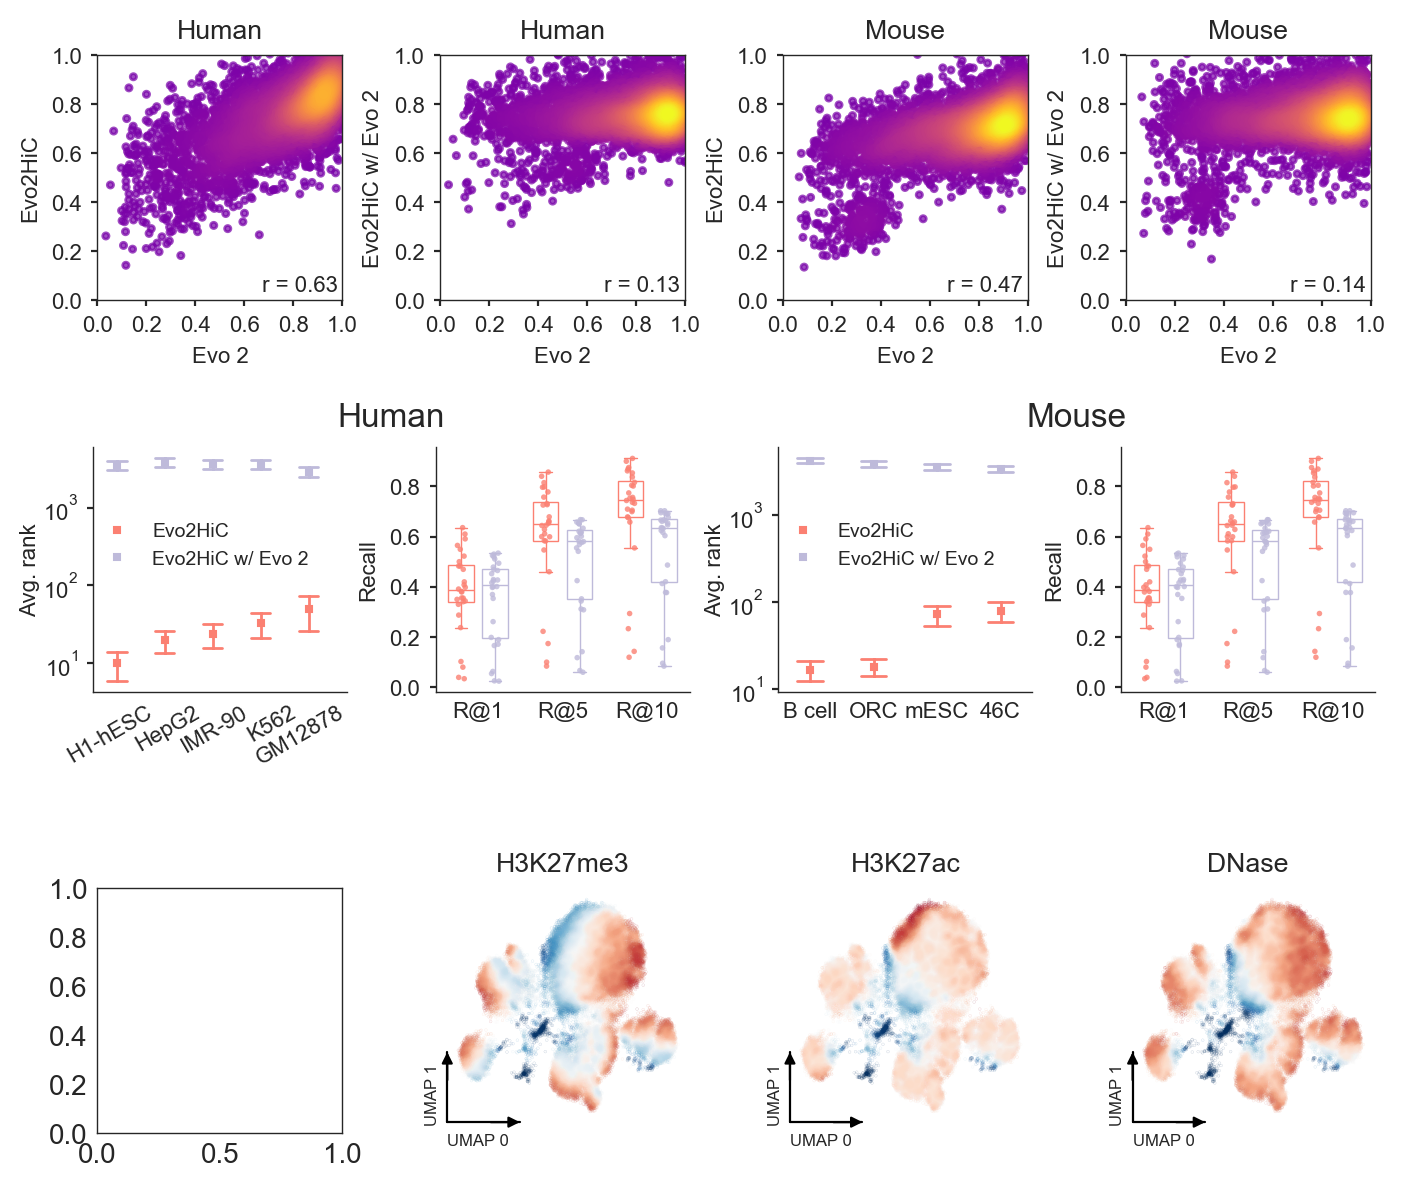

In [37]:


from scipy.stats import rankdata
import matplotlib.gridspec as gridspec

L, R, D = 1000, -1000, 1

percentiles = rankdata(a, axis=-1) / a.shape[-1]

ftracks = ['Average'] + tracks

k = 0.1
boundaries = [0, k, 1-k, 1]

cmap = 'RdBu_r'
norm=None
# cmap = mcolors.ListedColormap(["blue", "lightgrey", "red"])
# norm = mcolors.BoundaryNorm(boundaries, cmap.N)

def plot_umap(embeddings_umap, c, name, ax):
    ax.clear()
    ax.set_aspect('auto')

    x = embeddings_umap[L:R:D, 0]
    y = embeddings_umap[L:R:D, 1]
    val = c[L:R:D]

    mean_at_pts = kde_mean_2d(x, y, val, bw_method=0.05)  # 或 0.5/1.0 等因子微调带宽

    sc = ax.scatter(x, y, c=mean_at_pts, s=0.01, alpha=0.3, cmap=cmap, norm=norm, rasterized=True)

    sns.despine(ax=ax, bottom=True, left=True)
    # ax.set_xlabel('UMAP 0')
    # ax.set_ylabel('UMAP 1')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)

    # 获取当前坐标范围
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # 定义短坐标轴的长度比例
    frac = 0.3
    dx = (xmax - xmin) * frac
    dy = (ymax - ymin) * frac

    # 画出短线段（左下角）
    ax.plot([xmin, xmin + dx], [ymin, ymin], color='black', lw=0.8, clip_on=False)
    ax.plot([xmin, xmin], [ymin, ymin + dy], color='black', lw=0.8, clip_on=False)

    # 加上箭头
    ax.annotate('', xy=(xmin + dx, ymin), xytext=(xmin + dx*0.6, ymin),
                arrowprops=dict(arrowstyle='-|>', lw=0.8, color='black', shrinkA=0, shrinkB=0))
    ax.annotate('', xy=(xmin, ymin + dy), xytext=(xmin, ymin + dy*0.6),
                arrowprops=dict(arrowstyle='-|>', lw=0.8, color='black', shrinkA=0, shrinkB=0))

    # 可选：在箭头附近加个标签
    ax.text(xmin, ymin-1, 'UMAP 0', va='center', fontsize=6)
    ax.text(xmin-1, ymin, 'UMAP 1', ha='center', rotation=90, fontsize=6)

    return sc

sc1 = plot_umap(embeddings_umap, percentiles[3], tracks[3], axes[2][1])
sc2 = plot_umap(embeddings_umap, percentiles[2], tracks[2], axes[2][2])
sc3 = plot_umap(embeddings_umap, percentiles[0], tracks[0], axes[2][3])

fig

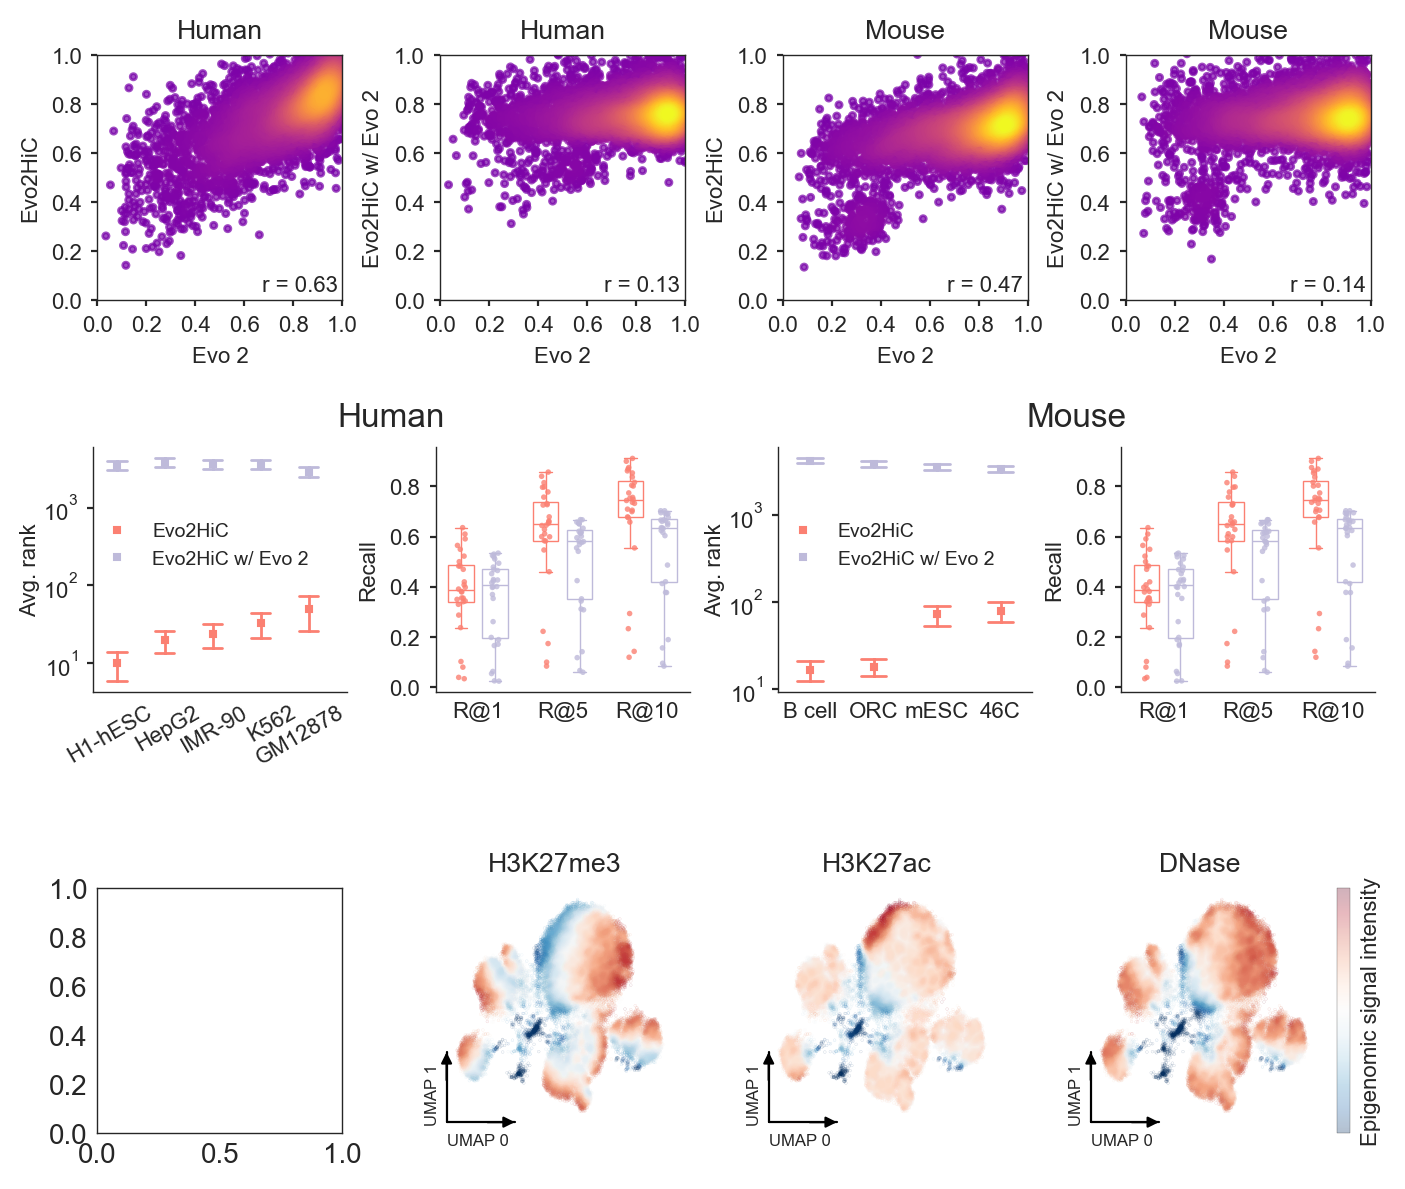

In [38]:
# 在最右侧加一个共用 colorbar
cb = fig.colorbar(sc3, ax=axes[2, 1:].ravel().tolist(), location='right',
                  fraction=0.04, pad=0.02)  # 可微调 fraction/pad
cb.outline.set_linewidth(0.1)
cb.set_ticks([])
cb.set_label('Epigenomic signal intensity')

fig

# 4. Inference cost

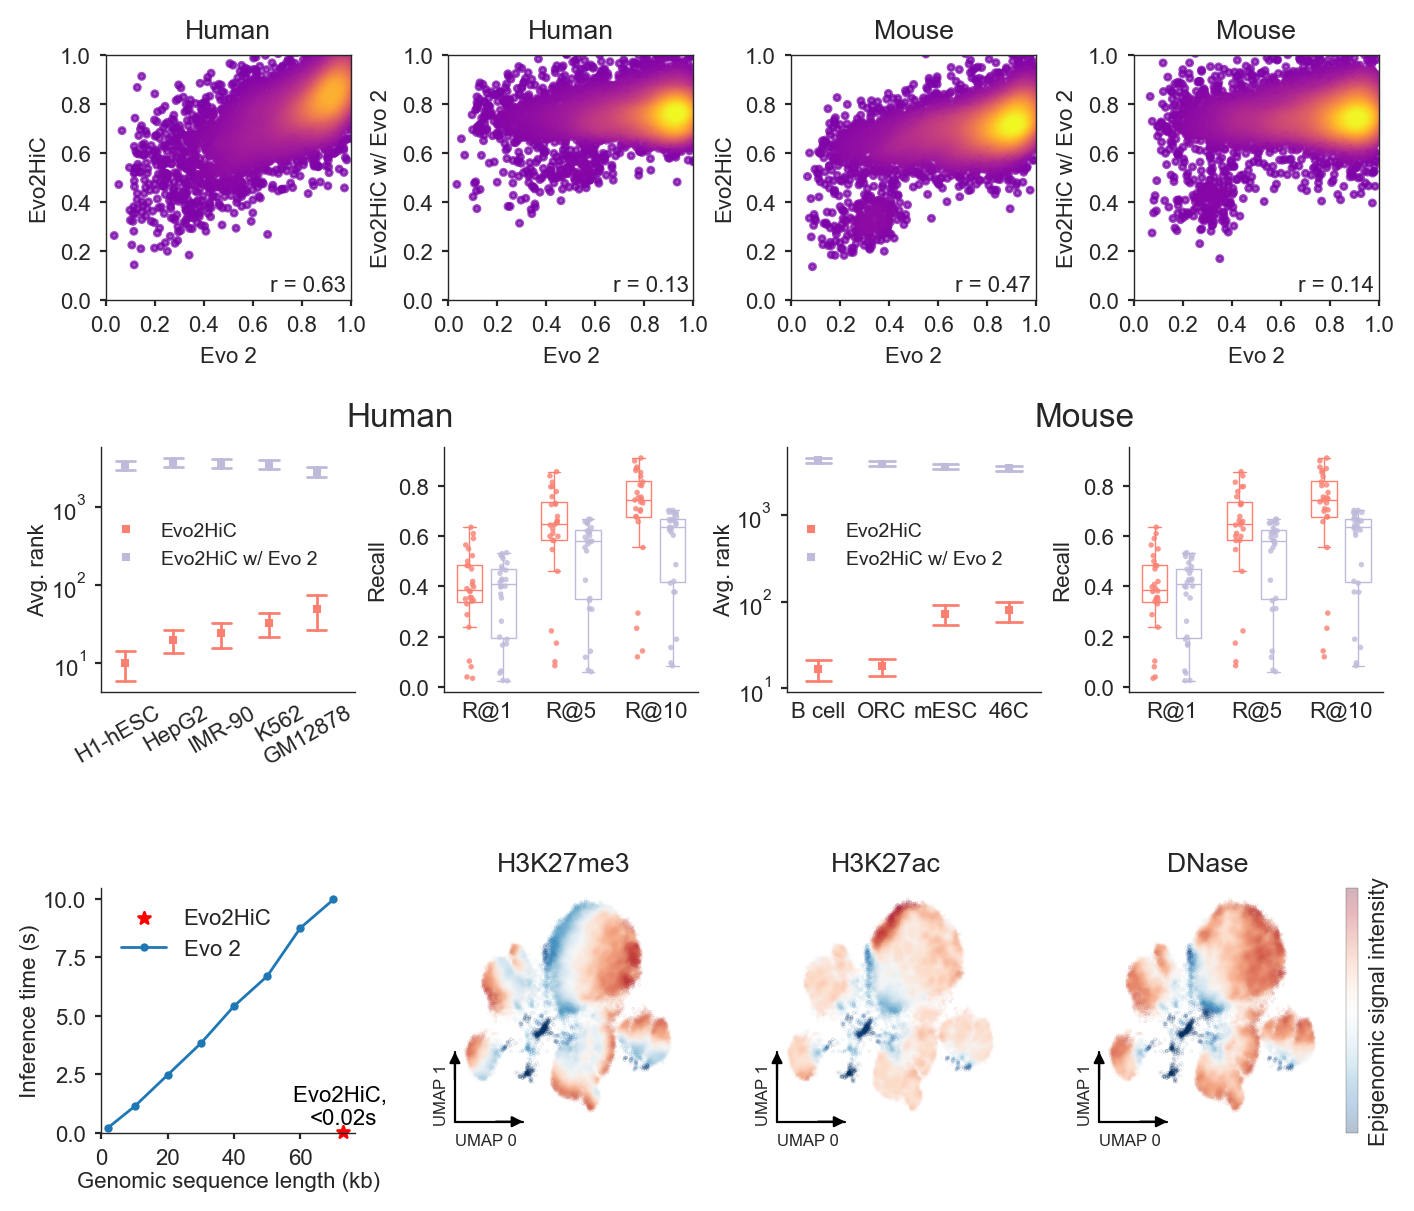

In [39]:
context_evo2 = np.array([2, 10, 20, 30, 40, 50, 60, 70])
time_evo2 = np.array([0.22, 1.13, 2.48, 3.83, 5.42, 6.70, 8.76, 9.98])
memory_evo2 = np.array([13.58193588256836, 18.61448383331299, 24.901814460754395, 31.1879243850708, 37.47877216339111, 43.76596260070801, 50.05349159240723, 56.34082221984863])

context_cnn = 73.016
time_cnn = 0.02
memory_cnn = 0.1968684196472168

ax = axes[2][0]
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.clear()
ax.set_aspect('auto')

ax.scatter(context_cnn, time_cnn, marker='*', s=20, color='red', label='Evo2HiC', clip_on=False)  # 五角星
ax.plot(context_evo2, time_evo2, 'o-', label='Evo 2', linewidth=1, ms=2)
ax.text(context_cnn, time_cnn+0.2, 'Evo2HiC, \n<0.02s', color='black',
         ha='center', va='bottom', fontsize='medium')

sns.despine(ax=ax)

ax.set_xlabel('Genomic sequence length (kb)')
ax.set_ylabel('Inference time (s)')
ax.xaxis.labelpad = 1
ax.yaxis.labelpad = 1
ax.legend()
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xticks(np.arange(0, 73, 20))
ax.tick_params(axis='both', length=2)
fig


# Final

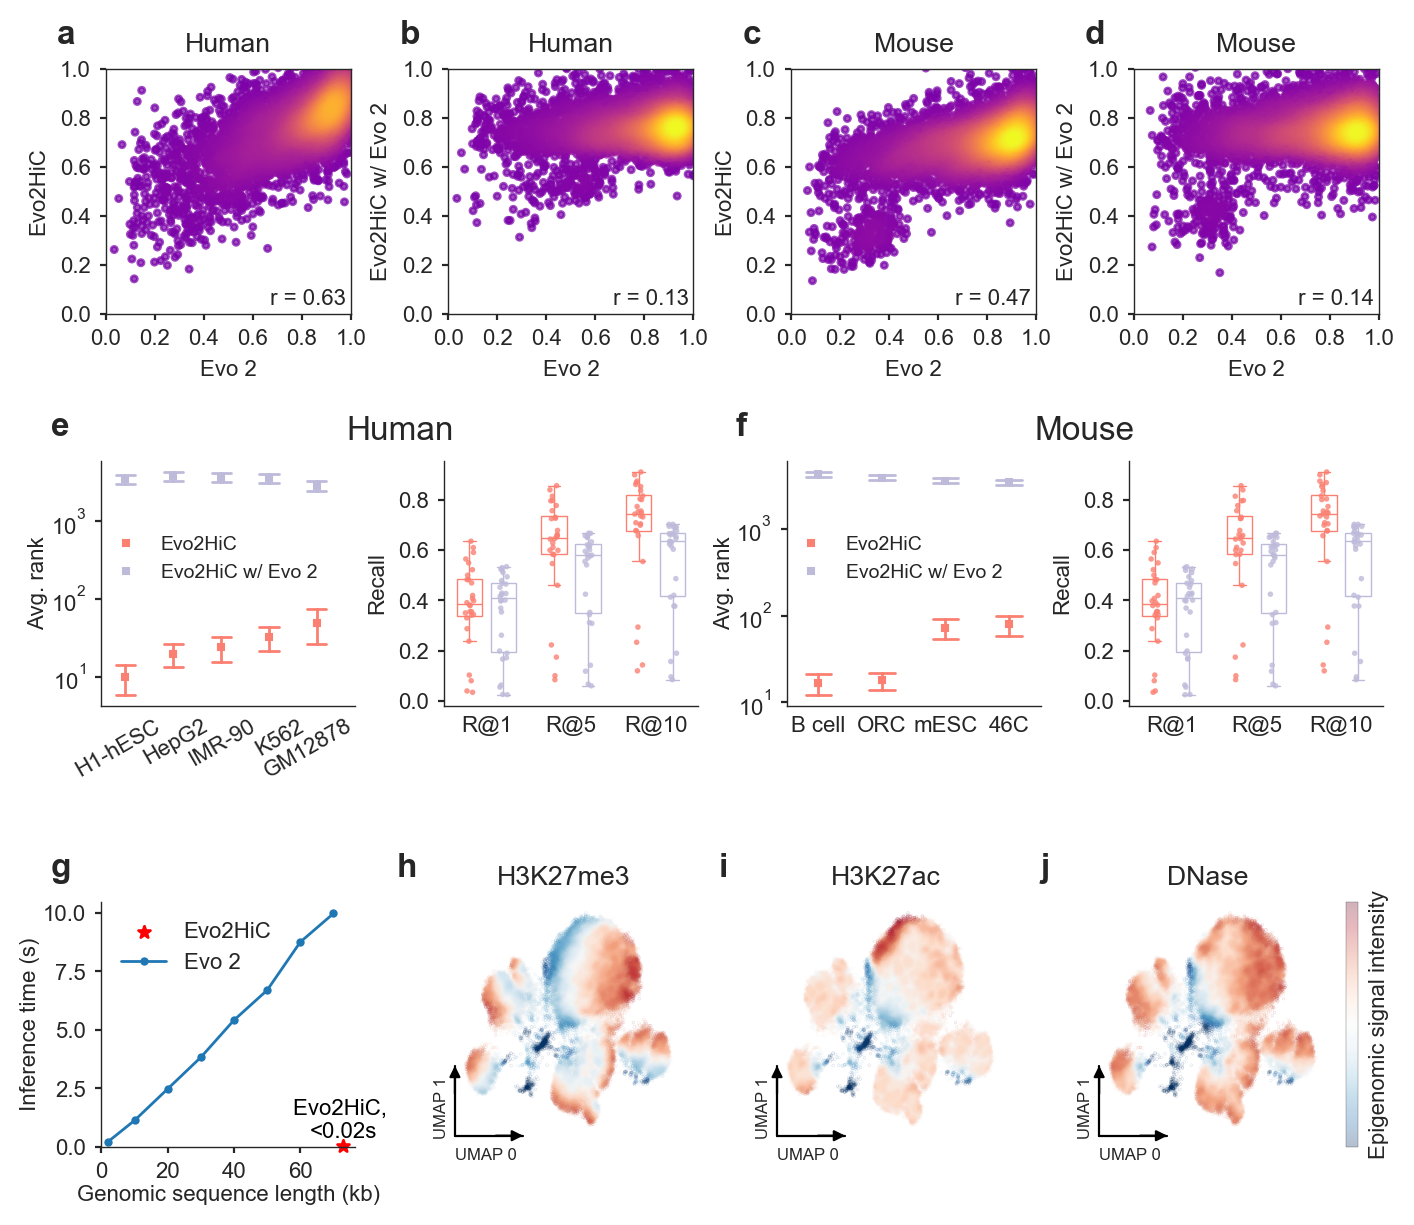

In [ ]:
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i','j']
axs = [axes[0][0], axes[0][1], axes[0][2], axes[0][3], axes[1][0], axes[1][2], axes[2][0], axes[2][1], axes[2][2], axes[2][3]]

for ax, label in zip(axs, labels):
    ax.text(
        -0.2, 1.2, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig

In [46]:
fig.savefig(str(OUT_DIR / 'Fig2.pdf'), dpi=600)